In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [32]:
data=pd.read_csv("weatherHistory.csv")
data

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [33]:
df=pd.DataFrame(data)

In [34]:
x = df[["Humidity"]]
y = df["Temperature (C)"]

In [35]:
model = LinearRegression()

In [36]:
model.fit(x, y)

LinearRegression()

In [37]:
y_pred = model.predict(x)

In [38]:
r2_score = r2_score(y, y_pred)

In [41]:
print("Slope (m):",model.coef_[0])
print("Intercept (c):",model.intercept_)
print("R2 Score:",r2_score)

Slope (m): -30.89438375805146
Intercept (c): 34.63692912688961
R2 Score: 0.3997459740945123


In [57]:
prediction = model.predict([[0.75]])
predicted_temp = prediction[0]
print("Predicted Temperature for 0.75 humidity:",predicted_temp)
min_temp = df['Temperature (C)'].min()
max_temp = df['Temperature (C)'].max()
if predicted_temp>=30:
    print("Weather condition: Sunny/Very Hot")
elif predicted_temp>=20:
    print("Weather condition: Warm Climate")
elif predicted_temp>=10:
    print("Weather condition: Cool Climate")
elif predicted_temp>=0:
    print("Weather condition: Cold Weather")
else:
    print("Weather condition: Freezing/Snow Climate")


Predicted Temperature for 0.75 humidity: 11.466141308351016
Weather condition: Cool Climate


C:\Users\tamil\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


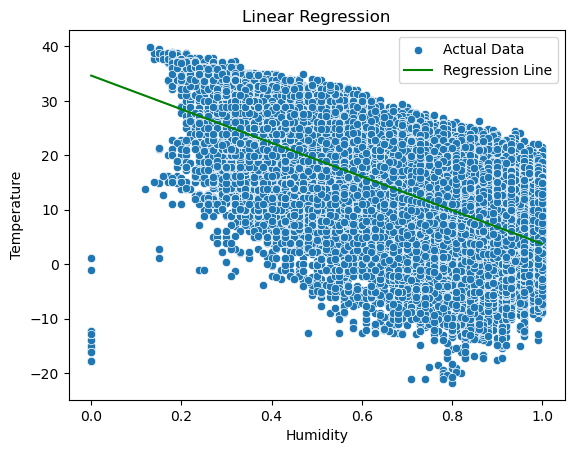

In [58]:
sns.scatterplot(x=x["Humidity"],y=y,label="Actual Data")
sns.lineplot(x=x["Humidity"],y=y_pred,color="green",label="Regression Line")
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Linear Regression")
plt.show()